In [1]:
import numpy as np
import pandas as pd

In [2]:
df=pd.read_csv(r"D:\DA\Data-Analytics-Mini-Project-\Dataset\unprocessed dataset (amazon sales).csv")
df.columns

Index(['OrderID', 'OrderDate', 'CustomerID', 'CustomerName', 'ProductID',
       'ProductName', 'Category', 'Brand', 'Quantity', 'UnitPrice', 'Discount',
       'Tax', 'ShippingCost', 'TotalAmount', 'PaymentMethod', 'OrderStatus',
       'Deliveredcity', 'Deliver_state', 'SellerID'],
      dtype='object')

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def get_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=np.unique(y_true))
    specificity = (cm[0,0] / (cm[0,0] + cm[0,1])) if cm.shape[0]>1 else 0
    return [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, average='weighted', zero_division=0),
        recall_score(y_true, y_pred, average='weighted', zero_division=0),
        f1_score(y_true, y_pred, average='weighted', zero_division=0),
        specificity
    ]

def bin_numeric(series, bins=5):
    return pd.qcut(series.rank(method='first'), q=bins, labels=False, duplicates='drop')

In [4]:
df_s = df.sample(2000, random_state=1)
X = pd.get_dummies(df_s[['OrderDate', 'Category', 'TotalAmount', 'PaymentMethod']])
y = df_s['OrderStatus'].astype(str)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

id3 = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=1)
c45 = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=1)
cart = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=1)
id3.fit(X_train, y_train)
c45.fit(X_train, y_train)
cart.fit(X_train, y_train)
perf = pd.DataFrame({
    "PERFORMANCE METRICES": ["ACCURRANCY", "PRECISSION", "RECALL", "F1 SCORE", "SPECIFICITY"],
    "ID3": get_metrics(y_test, id3.predict(X_test)),
    "C4.5": get_metrics(y_test, c45.predict(X_test)),
    "CART": get_metrics(y_test, cart.predict(X_test)),
})
print(perf)
best_algo = perf.iloc[0, 1:].idxmax()
print("Best algorithm for Q1:", best_algo)

  PERFORMANCE METRICES       ID3      C4.5      CART
0           ACCURRANCY  0.795000  0.795000  0.795000
1           PRECISSION  0.632025  0.632025  0.632025
2               RECALL  0.795000  0.795000  0.795000
3             F1 SCORE  0.704206  0.704206  0.704206
4          SPECIFICITY  0.000000  0.000000  0.000000
Best algorithm for Q1: ID3


In [5]:
if best_algo == "ID3":
    print("ID3 - Root Entropy:", id3.tree_.impurity[0])
elif best_algo == "C4.5":
    print("C4.5 - Root Entropy (proxy for Gain Ratio):", c45.tree_.impurity[0])
elif best_algo == "CART":
    print("CART - Root Gini Index:", cart.tree_.impurity[0])

ID3 - Root Entropy: 1.2936539656660042


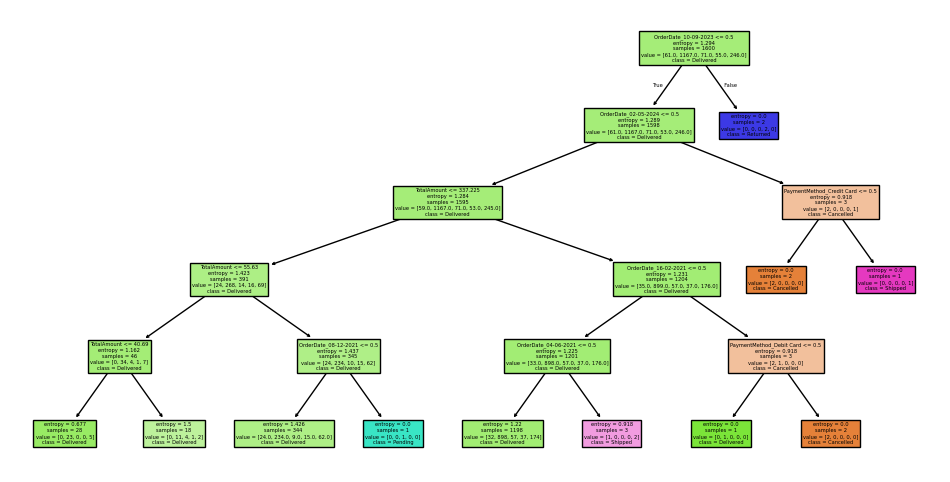

In [6]:
plt.figure(figsize=(12,6))
clf = {"ID3": id3, "C4.5": c45, "CART": cart}[best_algo]
plot_tree(clf, feature_names=X.columns, class_names=np.unique(y), filled=True)
plt.show()

In [7]:
df_s = df.sample(2000, random_state=2)
X = pd.get_dummies(df_s[['CustomerID', 'TotalAmount', 'PaymentMethod', 'Deliveredcity']])
y = df_s['OrderStatus'].astype(str)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

id3 = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=2)
c45 = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=2)
cart = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=2)
id3.fit(X_train, y_train)
c45.fit(X_train, y_train)
cart.fit(X_train, y_train)
perf = pd.DataFrame({
    "PERFORMANCE METRICES": ["ACCURRANCY", "PRECISSION", "RECALL", "F1 SCORE", "SPECIFICITY"],
    "ID3": get_metrics(y_test, id3.predict(X_test)),
    "C4.5": get_metrics(y_test, c45.predict(X_test)),
    "CART": get_metrics(y_test, cart.predict(X_test)),
})
print(perf)
best_algo = perf.iloc[0, 1:].idxmax()
print("Best algorithm for Q2:", best_algo)

  PERFORMANCE METRICES       ID3      C4.5      CART
0           ACCURRANCY  0.765000  0.767500  0.765000
1           PRECISSION  0.588609  0.589056  0.588609
2               RECALL  0.765000  0.767500  0.765000
3             F1 SCORE  0.665312  0.666542  0.665312
4          SPECIFICITY  0.000000  0.000000  0.000000
Best algorithm for Q2: C4.5


In [8]:
if best_algo == "ID3":
    print("ID3 - Root Entropy:", id3.tree_.impurity[0])
elif best_algo == "C4.5":
    print("C4.5 - Root Entropy (proxy for Gain Ratio):", c45.tree_.impurity[0])
elif best_algo == "CART":
    print("CART - Root Gini Index:", cart.tree_.impurity[0])

C4.5 - Root Entropy (proxy for Gain Ratio): 1.1739986901053518


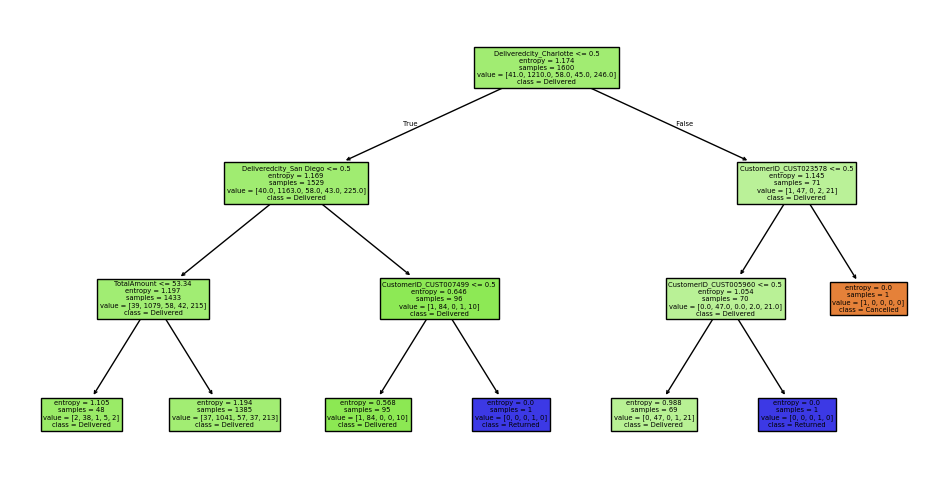

In [9]:
plt.figure(figsize=(12,6))
clf = {"ID3": id3, "C4.5": c45, "CART": cart}[best_algo]
plot_tree(clf, feature_names=X.columns, class_names=np.unique(y), filled=True)
plt.show()

In [10]:
df_s = df.sample(2000, random_state=3)
X = pd.get_dummies(df_s[['Discount', 'UnitPrice', 'Category', 'Brand']])
y = bin_numeric(df_s['Quantity'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=3)

id3 = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=3)
c45 = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=3)
cart = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=3)
id3.fit(X_train, y_train)
c45.fit(X_train, y_train)
cart.fit(X_train, y_train)
perf = pd.DataFrame({
    "PERFORMANCE METRICES": ["ACCURRANCY", "PRECISSION", "RECALL", "F1 SCORE", "SPECIFICITY"],
    "ID3": get_metrics(y_test, id3.predict(X_test)),
    "C4.5": get_metrics(y_test, c45.predict(X_test)),
    "CART": get_metrics(y_test, cart.predict(X_test)),
})
print(perf)
best_algo = perf.iloc[0, 1:].idxmax()
print("Best algorithm for Q3:", best_algo)

  PERFORMANCE METRICES       ID3      C4.5      CART
0           ACCURRANCY  0.180000  0.190000  0.175000
1           PRECISSION  0.151957  0.313948  0.168866
2               RECALL  0.180000  0.190000  0.175000
3             F1 SCORE  0.102924  0.108427  0.104612
4          SPECIFICITY  0.882353  0.984127  0.876923
Best algorithm for Q3: C4.5


In [11]:
if best_algo == "ID3":
    print("ID3 - Root Entropy:", id3.tree_.impurity[0])
elif best_algo == "C4.5":
    print("C4.5 - Root Entropy (proxy for Gain Ratio):", c45.tree_.impurity[0])
elif best_algo == "CART":
    print("CART - Root Gini Index:", cart.tree_.impurity[0])

C4.5 - Root Entropy (proxy for Gain Ratio): 2.321750311523394


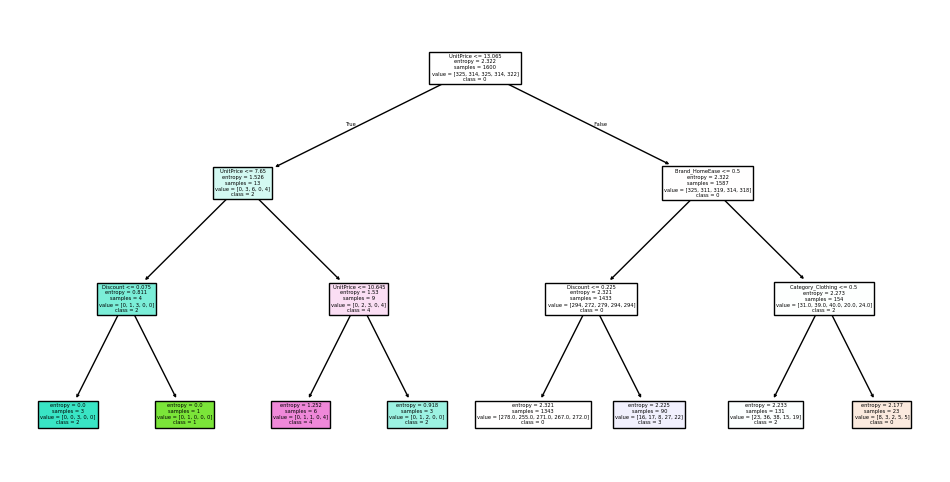

In [12]:
plt.figure(figsize=(12,6))
clf = {"ID3": id3, "C4.5": c45, "CART": cart}[best_algo]
plot_tree(clf, feature_names=X.columns, class_names=[str(x) for x in np.unique(y)], filled=True)
plt.show()

In [13]:
df_s = df.sample(2000, random_state=4)
X = pd.get_dummies(df_s[['Quantity', 'Category', 'UnitPrice', 'Brand']])
y = bin_numeric(df_s['Discount'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)

id3 = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=4)
c45 = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=4)
cart = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=4)
id3.fit(X_train, y_train)
c45.fit(X_train, y_train)
cart.fit(X_train, y_train)
perf = pd.DataFrame({
    "PERFORMANCE METRICES": ["ACCURRANCY", "PRECISSION", "RECALL", "F1 SCORE", "SPECIFICITY"],
    "ID3": get_metrics(y_test, id3.predict(X_test)),
    "C4.5": get_metrics(y_test, c45.predict(X_test)),
    "CART": get_metrics(y_test, cart.predict(X_test)),
})
print(perf)
best_algo = perf.iloc[0, 1:].idxmax()
print("Best algorithm for Q4:", best_algo)

  PERFORMANCE METRICES       ID3      C4.5      CART
0           ACCURRANCY  0.217500  0.202500  0.222500
1           PRECISSION  0.184763  0.112369  0.203203
2               RECALL  0.217500  0.202500  0.222500
3             F1 SCORE  0.148157  0.125387  0.151783
4          SPECIFICITY  1.000000  0.805195  1.000000
Best algorithm for Q4: CART


In [14]:
if best_algo == "ID3":
    print("ID3 - Root Entropy:", id3.tree_.impurity[0])
elif best_algo == "C4.5":
    print("C4.5 - Root Entropy (proxy for Gain Ratio):", c45.tree_.impurity[0])
elif best_algo == "CART":
    print("CART - Root Gini Index:", cart.tree_.impurity[0])

CART - Root Gini Index: 0.79990546875


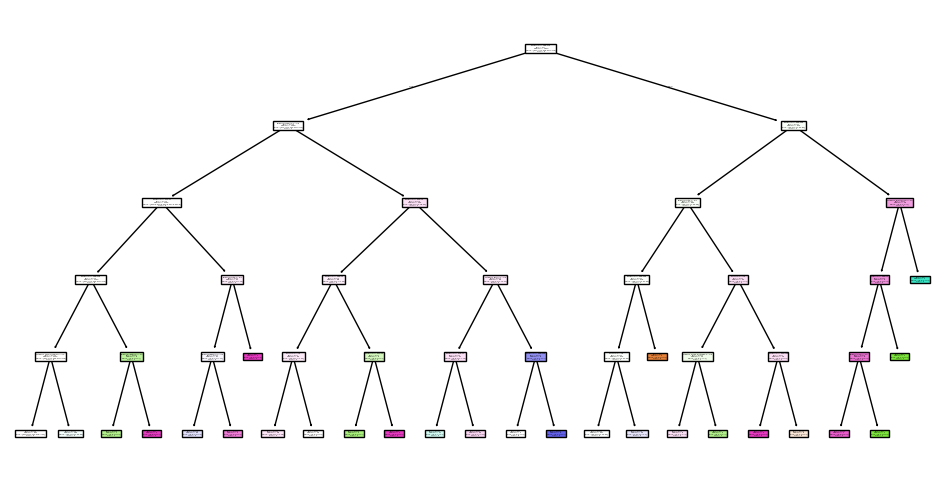

In [15]:
plt.figure(figsize=(12,6))
clf = {"ID3": id3, "C4.5": c45, "CART": cart}[best_algo]
plot_tree(clf, feature_names=X.columns, class_names=[str(x) for x in np.unique(y)], filled=True)
plt.show()

In [16]:
df_s = df.sample(2000, random_state=5)
X = pd.get_dummies(df_s[['ProductID', 'OrderDate', 'Category']])
y = bin_numeric(df_s['Quantity'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5)

id3 = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=5)
c45 = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=5)
cart = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=5)
id3.fit(X_train, y_train)
c45.fit(X_train, y_train)
cart.fit(X_train, y_train)
perf = pd.DataFrame({
    "PERFORMANCE METRICES": ["ACCURRANCY", "PRECISSION", "RECALL", "F1 SCORE", "SPECIFICITY"],
    "ID3": get_metrics(y_test, id3.predict(X_test)),
    "C4.5": get_metrics(y_test, c45.predict(X_test)),
    "CART": get_metrics(y_test, cart.predict(X_test)),
})
print(perf)
best_algo = perf.iloc[0, 1:].idxmax()
print("Best algorithm for Q5:", best_algo)

  PERFORMANCE METRICES      ID3     C4.5      CART
0           ACCURRANCY  0.19250  0.19000  0.180000
1           PRECISSION  0.10078  0.18701  0.155157
2               RECALL  0.19250  0.19000  0.180000
3             F1 SCORE  0.08236  0.07638  0.063162
4          SPECIFICITY  0.75000  1.00000  1.000000
Best algorithm for Q5: ID3


In [17]:
if best_algo == "ID3":
    print("ID3 - Root Entropy:", id3.tree_.impurity[0])
elif best_algo == "C4.5":
    print("C4.5 - Root Entropy (proxy for Gain Ratio):", c45.tree_.impurity[0])
elif best_algo == "CART":
    print("CART - Root Gini Index:", cart.tree_.impurity[0])

ID3 - Root Entropy: 2.3217313591914674


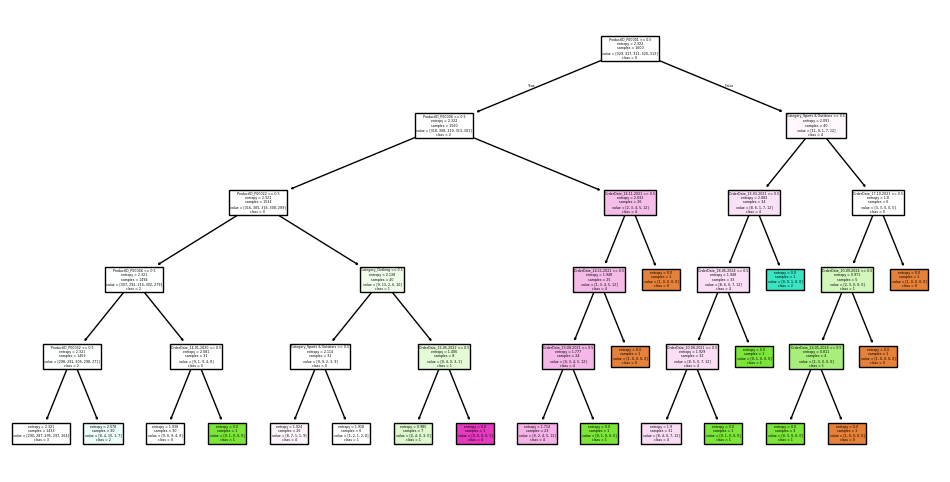

In [18]:
plt.figure(figsize=(12,6))
clf = {"ID3": id3, "C4.5": c45, "CART": cart}[best_algo]
plot_tree(clf, feature_names=X.columns, class_names=[str(x) for x in np.unique(y)], filled=True)
plt.show()

In [20]:
df_s = df.sample(2000, random_state=6)
X = pd.get_dummies(df_s[['CustomerID', 'Category', 'Brand', 'UnitPrice']])
y = df_s['ProductID'].astype(str)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=6)

id3 = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=6)
c45 = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=6)
cart = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=6)
id3.fit(X_train, y_train)
c45.fit(X_train, y_train)
cart.fit(X_train, y_train)
perf = pd.DataFrame({
    "PERFORMANCE METRICES": ["ACCURRANCY", "PRECISSION", "RECALL", "F1 SCORE", "SPECIFICITY"],
    "ID3": get_metrics(y_test, id3.predict(X_test)),
    "C4.5": get_metrics(y_test, c45.predict(X_test)),
    "CART": get_metrics(y_test, cart.predict(X_test)),
})
print(perf)
best_algo = perf.iloc[0, 1:].idxmax()
print("Best algorithm for Q6:", best_algo)

  PERFORMANCE METRICES       ID3      C4.5      CART
0           ACCURRANCY  0.025000  0.017500  0.017500
1           PRECISSION  0.015854  0.003533  0.001663
2               RECALL  0.025000  0.017500  0.017500
3             F1 SCORE  0.011189  0.004365  0.002854
4          SPECIFICITY       NaN       NaN       NaN
Best algorithm for Q6: ID3


C:\Users\AID-DLL-056\AppData\Local\Temp\ipykernel_16768\150627700.py:10: RuntimeWarning: invalid value encountered in scalar divide
  specificity = (cm[0,0] / (cm[0,0] + cm[0,1])) if cm.shape[0]>1 else 0
C:\Users\AID-DLL-056\AppData\Local\Temp\ipykernel_16768\150627700.py:10: RuntimeWarning: invalid value encountered in scalar divide
  specificity = (cm[0,0] / (cm[0,0] + cm[0,1])) if cm.shape[0]>1 else 0
C:\Users\AID-DLL-056\AppData\Local\Temp\ipykernel_16768\150627700.py:10: RuntimeWarning: invalid value encountered in scalar divide
  specificity = (cm[0,0] / (cm[0,0] + cm[0,1])) if cm.shape[0]>1 else 0


In [21]:
if best_algo == "ID3":
    print("ID3 - Root Entropy:", id3.tree_.impurity[0])
elif best_algo == "C4.5":
    print("C4.5 - Root Entropy (proxy for Gain Ratio):", c45.tree_.impurity[0])
elif best_algo == "CART":
    print("CART - Root Gini Index:", cart.tree_.impurity[0])

ID3 - Root Entropy: 5.616001430383419


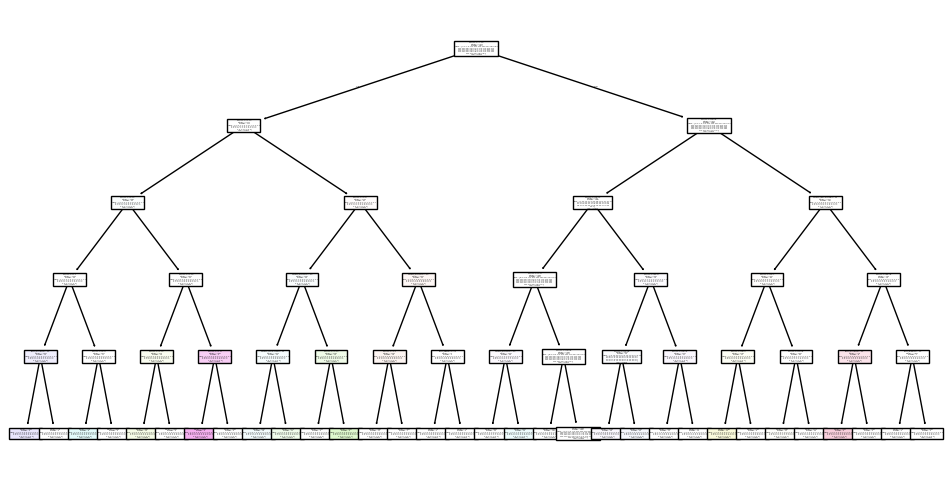

In [22]:
plt.figure(figsize=(12,6))
clf = {"ID3": id3, "C4.5": c45, "CART": cart}[best_algo]
plot_tree(clf, feature_names=X.columns, class_names=np.unique(y), filled=True)
plt.show()

In [23]:
df_s = df.sample(2000, random_state=7)
X = pd.get_dummies(df_s[['OrderDate', 'ProductID', 'Category']])
y = bin_numeric(df_s['Quantity'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7)

id3 = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=7)
c45 = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=7)
cart = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=7)
id3.fit(X_train, y_train)
c45.fit(X_train, y_train)
cart.fit(X_train, y_train)
perf = pd.DataFrame({
    "PERFORMANCE METRICES": ["ACCURRANCY", "PRECISSION", "RECALL", "F1 SCORE", "SPECIFICITY"],
    "ID3": get_metrics(y_test, id3.predict(X_test)),
    "C4.5": get_metrics(y_test, c45.predict(X_test)),
    "CART": get_metrics(y_test, cart.predict(X_test)),
})
print(perf)
best_algo = perf.iloc[0, 1:].idxmax()
print("Best algorithm for Q7:", best_algo)

  PERFORMANCE METRICES       ID3      C4.5      CART
0           ACCURRANCY  0.170000  0.170000  0.172500
1           PRECISSION  0.203265  0.203265  0.029756
2               RECALL  0.170000  0.170000  0.172500
3             F1 SCORE  0.056911  0.056911  0.050757
4          SPECIFICITY  0.014706  0.014706  1.000000
Best algorithm for Q7: CART


In [24]:
if best_algo == "ID3":
    print("ID3 - Root Entropy:", id3.tree_.impurity[0])
elif best_algo == "C4.5":
    print("C4.5 - Root Entropy (proxy for Gain Ratio):", c45.tree_.impurity[0])
elif best_algo == "CART":
    print("CART - Root Gini Index:", cart.tree_.impurity[0])

CART - Root Gini Index: 0.7998734375000001


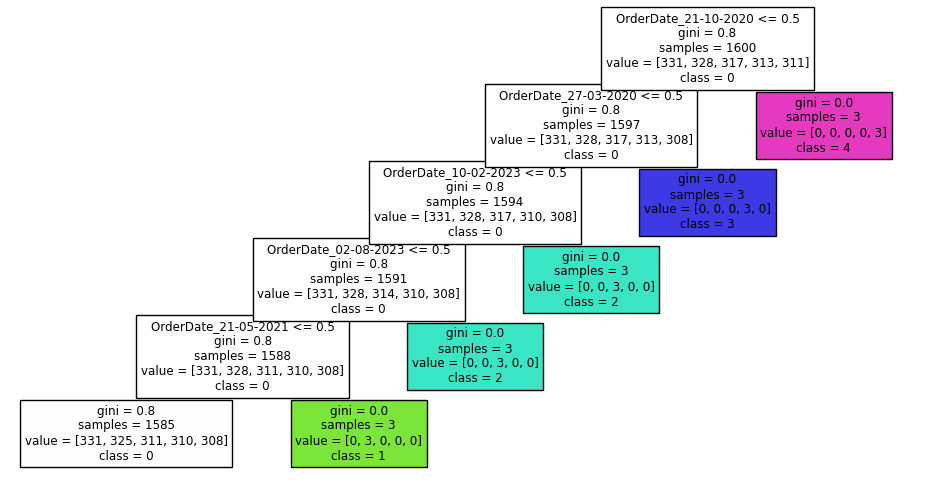

In [25]:
plt.figure(figsize=(12,6))
clf = {"ID3": id3, "C4.5": c45, "CART": cart}[best_algo]
plot_tree(clf, feature_names=X.columns, class_names=[str(x) for x in np.unique(y)], filled=True)
plt.show()

In [26]:
df_s = df.sample(2000, random_state=8)
X = pd.get_dummies(df_s[['Deliveredcity', 'Deliver_state', 'Quantity', 'TotalAmount']])
y = bin_numeric(df_s['ShippingCost'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=8)

id3 = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=8)
c45 = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=8)
cart = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=8)
id3.fit(X_train, y_train)
c45.fit(X_train, y_train)
cart.fit(X_train, y_train)
perf = pd.DataFrame({
    "PERFORMANCE METRICES": ["ACCURRANCY", "PRECISSION", "RECALL", "F1 SCORE", "SPECIFICITY"],
    "ID3": get_metrics(y_test, id3.predict(X_test)),
    "C4.5": get_metrics(y_test, c45.predict(X_test)),
    "CART": get_metrics(y_test, cart.predict(X_test)),
})
print(perf)
best_algo = perf.iloc[0, 1:].idxmax()
print("Best algorithm for Q8:", best_algo)

  PERFORMANCE METRICES       ID3      C4.5      CART
0           ACCURRANCY  0.192500  0.212500  0.210000
1           PRECISSION  0.184223  0.210834  0.236593
2               RECALL  0.192500  0.212500  0.210000
3             F1 SCORE  0.137489  0.126192  0.120796
4          SPECIFICITY  0.040000  0.400000  1.000000
Best algorithm for Q8: C4.5


In [27]:
if best_algo == "ID3":
    print("ID3 - Root Entropy:", id3.tree_.impurity[0])
elif best_algo == "C4.5":
    print("C4.5 - Root Entropy (proxy for Gain Ratio):", c45.tree_.impurity[0])
elif best_algo == "CART":
    print("CART - Root Gini Index:", cart.tree_.impurity[0])

C4.5 - Root Entropy (proxy for Gain Ratio): 2.3218465874991168


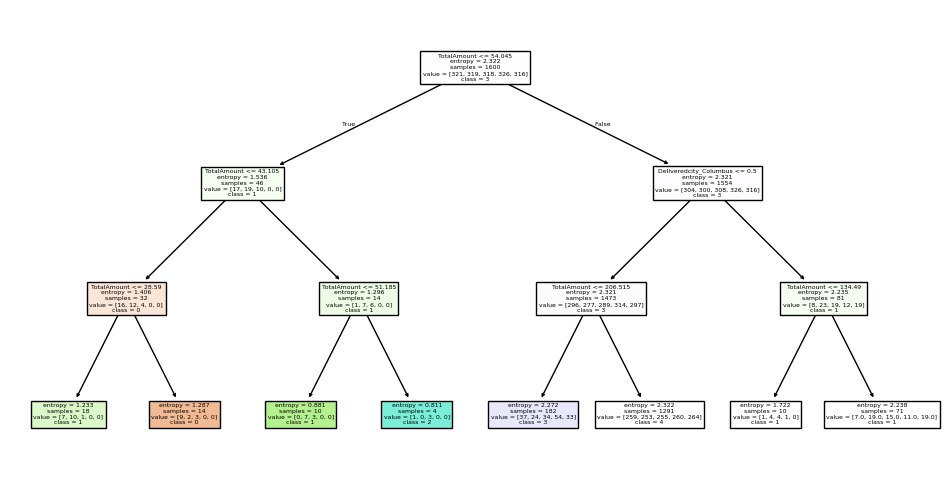

In [28]:
plt.figure(figsize=(12,6))
clf = {"ID3": id3, "C4.5": c45, "CART": cart}[best_algo]
plot_tree(clf, feature_names=X.columns, class_names=[str(x) for x in np.unique(y)], filled=True)
plt.show()

In [29]:
df_s = df.sample(2000, random_state=9)
X = pd.get_dummies(df_s[['ProductID', 'Category', 'TotalAmount', 'CustomerID']])
y = df_s['OrderID'].astype(str)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=9)

id3 = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=9)
c45 = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=9)
cart = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=9)
id3.fit(X_train, y_train)
c45.fit(X_train, y_train)
cart.fit(X_train, y_train)
perf = pd.DataFrame({
    "PERFORMANCE METRICES": ["ACCURRANCY", "PRECISSION", "RECALL", "F1 SCORE", "SPECIFICITY"],
    "ID3": get_metrics(y_test, id3.predict(X_test)),
    "C4.5": get_metrics(y_test, c45.predict(X_test)),
    "CART": get_metrics(y_test, cart.predict(X_test)),
})
print(perf)
best_algo = perf.iloc[0, 1:].idxmax()
print("Best algorithm for Q9:", best_algo)

C:\Users\AID-DLL-056\AppData\Roaming\Python\Python313\site-packages\sklearn\tree\_classes.py:297: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
C:\Users\AID-DLL-056\AppData\Roaming\Python\Python313\site-packages\sklearn\tree\_classes.py:297: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)


  PERFORMANCE METRICES  ID3  C4.5  CART
0           ACCURRANCY  0.0   0.0   0.0
1           PRECISSION  0.0   0.0   0.0
2               RECALL  0.0   0.0   0.0
3             F1 SCORE  0.0   0.0   0.0
4          SPECIFICITY  NaN   NaN   NaN
Best algorithm for Q9: ID3


C:\Users\AID-DLL-056\AppData\Roaming\Python\Python313\site-packages\sklearn\tree\_classes.py:297: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
C:\Users\AID-DLL-056\AppData\Local\Temp\ipykernel_16768\150627700.py:10: RuntimeWarning: invalid value encountered in scalar divide
  specificity = (cm[0,0] / (cm[0,0] + cm[0,1])) if cm.shape[0]>1 else 0
C:\Users\AID-DLL-056\AppData\Local\Temp\ipykernel_16768\150627700.py:10: RuntimeWarning: invalid value encountered in scalar divide
  specificity = (cm[0,0] / (cm[0,0] + cm[0,1])) if cm.shape[0]>1 else 0
C:\Users\AID-DLL-056\AppData\Local\Temp\ipykernel_16768\150627700.py:10: RuntimeWarning: invalid value encountered in scalar divide
  specificity = (cm[0,0] / (cm[0,0] + cm[0,1])) if cm.shape[0]>1 else 0


In [30]:
if best_algo == "ID3":
    print("ID3 - Root Entropy:", id3.tree_.impurity[0])
elif best_algo == "C4.5":
    print("C4.5 - Root Entropy (proxy for Gain Ratio):", c45.tree_.impurity[0])
elif best_algo == "CART":
    print("CART - Root Gini Index:", cart.tree_.impurity[0])

ID3 - Root Entropy: 10.643856189775036


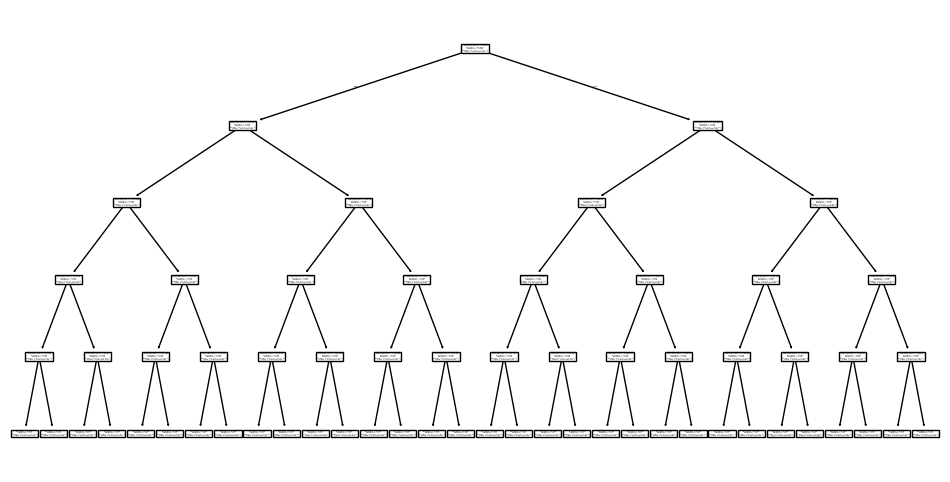

In [31]:
plt.figure(figsize=(12,6))
clf = {"ID3": id3, "C4.5": c45, "CART": cart}[best_algo]
plot_tree(clf, feature_names=X.columns, class_names=np.unique(y), filled=True)
plt.show()

In [32]:
df_s = df.sample(2000, random_state=10)
X = pd.get_dummies(df_s[['OrderDate', 'Discount', 'Brand', 'Category']])
y = bin_numeric(df_s['UnitPrice'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

id3 = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=10)
c45 = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=10)
cart = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=10)
id3.fit(X_train, y_train)
c45.fit(X_train, y_train)
cart.fit(X_train, y_train)
perf = pd.DataFrame({
    "PERFORMANCE METRICES": ["ACCURRANCY", "PRECISSION", "RECALL", "F1 SCORE", "SPECIFICITY"],
    "ID3": get_metrics(y_test, id3.predict(X_test)),
    "C4.5": get_metrics(y_test, c45.predict(X_test)),
    "CART": get_metrics(y_test, cart.predict(X_test)),
})
print(perf)
best_algo = perf.iloc[0, 1:].idxmax()
print("Best algorithm for Q10:", best_algo)

  PERFORMANCE METRICES       ID3      C4.5      CART
0           ACCURRANCY  0.202500  0.177500  0.185000
1           PRECISSION  0.283301  0.143748  0.139537
2               RECALL  0.202500  0.177500  0.185000
3             F1 SCORE  0.144255  0.096684  0.094756
4          SPECIFICITY  1.000000  0.014925  0.000000
Best algorithm for Q10: ID3


In [33]:
if best_algo == "ID3":
    print("ID3 - Root Entropy:", id3.tree_.impurity[0])
elif best_algo == "C4.5":
    print("C4.5 - Root Entropy (proxy for Gain Ratio):", c45.tree_.impurity[0])
elif best_algo == "CART":
    print("CART - Root Gini Index:", cart.tree_.impurity[0])

ID3 - Root Entropy: 2.3218830094931926


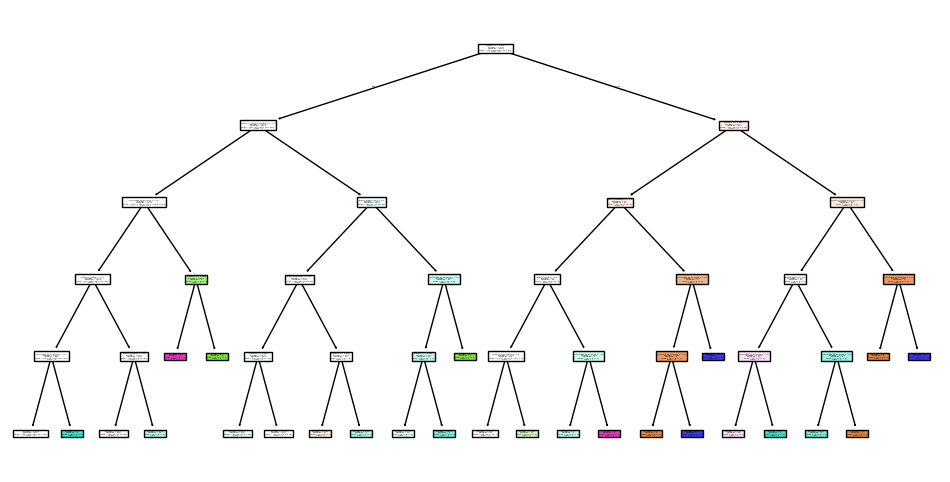

In [34]:
plt.figure(figsize=(12,6))
clf = {"ID3": id3, "C4.5": c45, "CART": cart}[best_algo]
plot_tree(clf, feature_names=X.columns, class_names=[str(x) for x in np.unique(y)], filled=True)
plt.show()

In [35]:
df_s = df.sample(2000, random_state=11)
X = pd.get_dummies(df_s[['ProductName', 'ProductID', 'Brand', 'UnitPrice']])
y = df_s['Category'].astype(str)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=11)

id3 = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=11)
c45 = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=11)
cart = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=11)
id3.fit(X_train, y_train)
c45.fit(X_train, y_train)
cart.fit(X_train, y_train)
perf = pd.DataFrame({
    "PERFORMANCE METRICES": ["ACCURRANCY", "PRECISSION", "RECALL", "F1 SCORE", "SPECIFICITY"],
    "ID3": get_metrics(y_test, id3.predict(X_test)),
    "C4.5": get_metrics(y_test, c45.predict(X_test)),
    "CART": get_metrics(y_test, cart.predict(X_test)),
})
print(perf)
best_algo = perf.iloc[0, 1:].idxmax()
print("Best algorithm for Q11:", best_algo)

  PERFORMANCE METRICES       ID3      C4.5      CART
0           ACCURRANCY  0.160000  0.167500  0.140000
1           PRECISSION  0.218242  0.098547  0.199245
2               RECALL  0.160000  0.167500  0.140000
3             F1 SCORE  0.082385  0.071198  0.082699
4          SPECIFICITY  1.000000  0.000000  0.500000
Best algorithm for Q11: C4.5


In [36]:
if best_algo == "ID3":
    print("ID3 - Root Entropy:", id3.tree_.impurity[0])
elif best_algo == "C4.5":
    print("C4.5 - Root Entropy (proxy for Gain Ratio):", c45.tree_.impurity[0])
elif best_algo == "CART":
    print("CART - Root Gini Index:", cart.tree_.impurity[0])

C4.5 - Root Entropy (proxy for Gain Ratio): 2.584034955348478


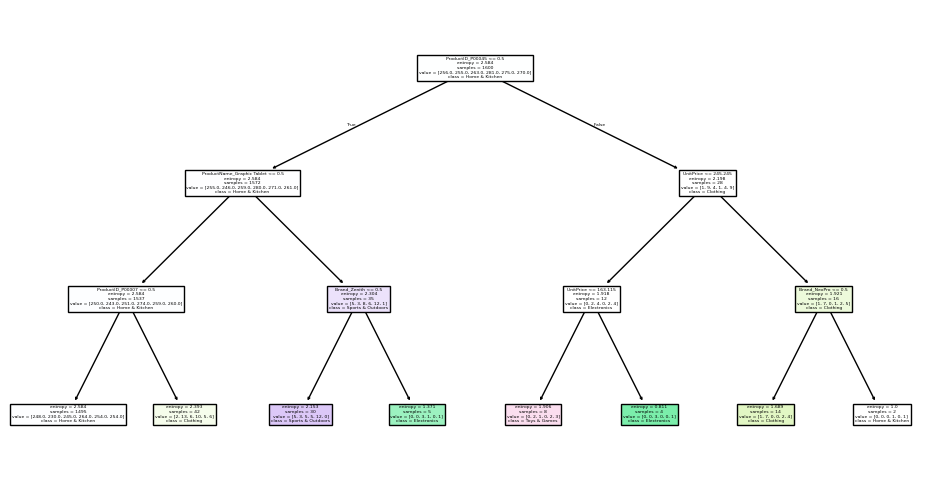

In [37]:
plt.figure(figsize=(12,6))
clf = {"ID3": id3, "C4.5": c45, "CART": cart}[best_algo]
plot_tree(clf, feature_names=X.columns, class_names=np.unique(y), filled=True)
plt.show()

In [38]:
df_s = df.sample(2000, random_state=12)
X = pd.get_dummies(df_s[['Category', 'ProductName', 'Deliver_state', 'UnitPrice']])
y = bin_numeric(df_s['Tax'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12)

id3 = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=12)
c45 = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=12)
cart = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=12)
id3.fit(X_train, y_train)
c45.fit(X_train, y_train)
cart.fit(X_train, y_train)
perf = pd.DataFrame({
    "PERFORMANCE METRICES": ["ACCURRANCY", "PRECISSION", "RECALL", "F1 SCORE", "SPECIFICITY"],
    "ID3": get_metrics(y_test, id3.predict(X_test)),
    "C4.5": get_metrics(y_test, c45.predict(X_test)),
    "CART": get_metrics(y_test, cart.predict(X_test)),
})
print(perf)
best_algo = perf.iloc[0, 1:].idxmax()
print("Best algorithm for Q12:", best_algo)

  PERFORMANCE METRICES       ID3      C4.5      CART
0           ACCURRANCY  0.377500  0.420000  0.390000
1           PRECISSION  0.405061  0.454878  0.452408
2               RECALL  0.377500  0.420000  0.390000
3             F1 SCORE  0.378683  0.407614  0.357355
4          SPECIFICITY  0.610169  0.593220  0.500000
Best algorithm for Q12: C4.5


In [39]:
if best_algo == "ID3":
    print("ID3 - Root Entropy:", id3.tree_.impurity[0])
elif best_algo == "C4.5":
    print("C4.5 - Root Entropy (proxy for Gain Ratio):", c45.tree_.impurity[0])
elif best_algo == "CART":
    print("CART - Root Gini Index:", cart.tree_.impurity[0])

C4.5 - Root Entropy (proxy for Gain Ratio): 2.3218075639615328


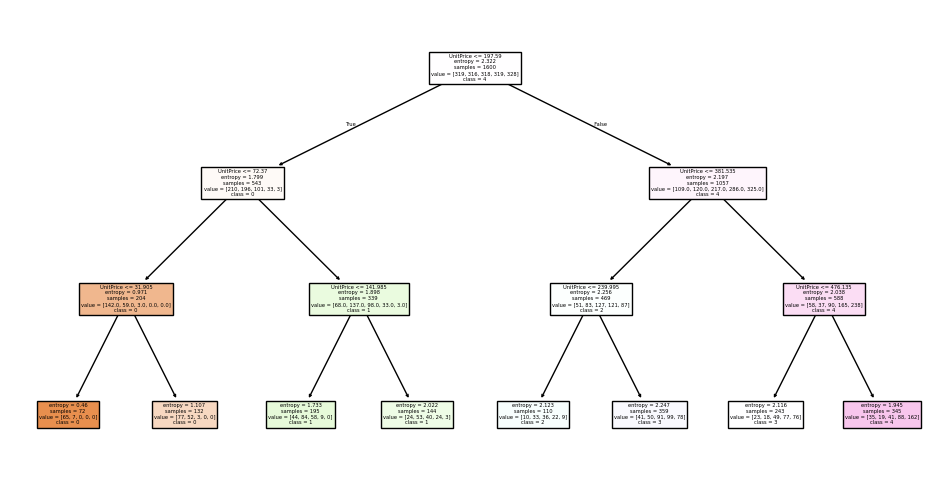

In [40]:
plt.figure(figsize=(12,6))
clf = {"ID3": id3, "C4.5": c45, "CART": cart}[best_algo]
plot_tree(clf, feature_names=X.columns, class_names=[str(x) for x in np.unique(y)], filled=True)
plt.show()

In [41]:
df_s = df.sample(2000, random_state=13)
X = pd.get_dummies(df_s[['CustomerID', 'OrderDate', 'Quantity']])
y = bin_numeric(df_s['TotalAmount'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=13)

id3 = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=13)
c45 = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=13)
cart = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=13)
id3.fit(X_train, y_train)
c45.fit(X_train, y_train)
cart.fit(X_train, y_train)
perf = pd.DataFrame({
    "PERFORMANCE METRICES": ["ACCURRANCY", "PRECISSION", "RECALL", "F1 SCORE", "SPECIFICITY"],
    "ID3": get_metrics(y_test, id3.predict(X_test)),
    "C4.5": get_metrics(y_test, c45.predict(X_test)),
    "CART": get_metrics(y_test, cart.predict(X_test)),
})
print(perf)
best_algo = perf.iloc[0, 1:].idxmax()
print("Best algorithm for Q13:", best_algo)

  PERFORMANCE METRICES       ID3      C4.5      CART
0           ACCURRANCY  0.372500  0.375000  0.372500
1           PRECISSION  0.298188  0.299625  0.298188
2               RECALL  0.372500  0.375000  0.372500
3             F1 SCORE  0.319062  0.320634  0.319062
4          SPECIFICITY  1.000000  1.000000  1.000000
Best algorithm for Q13: C4.5


In [42]:
if best_algo == "ID3":
    print("ID3 - Root Entropy:", id3.tree_.impurity[0])
elif best_algo == "C4.5":
    print("C4.5 - Root Entropy (proxy for Gain Ratio):", c45.tree_.impurity[0])
elif best_algo == "CART":
    print("CART - Root Gini Index:", cart.tree_.impurity[0])

C4.5 - Root Entropy (proxy for Gain Ratio): 2.32183228768165


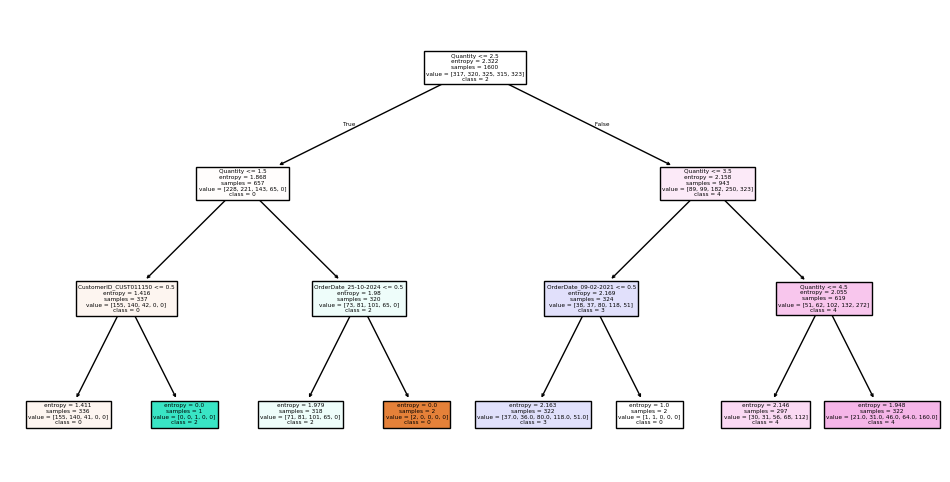

In [43]:
plt.figure(figsize=(12,6))
clf = {"ID3": id3, "C4.5": c45, "CART": cart}[best_algo]
plot_tree(clf, feature_names=X.columns, class_names=[str(x) for x in np.unique(y)], filled=True)
plt.show()

In [44]:
df_s = df.sample(2000, random_state=14)
X = pd.get_dummies(df_s[['Deliveredcity', 'Deliver_state', 'ShippingCost', 'Tax']])
y = bin_numeric(df_s['TotalAmount'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=14)

id3 = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=14)
c45 = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=14)
cart = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=14)
id3.fit(X_train, y_train)
c45.fit(X_train, y_train)
cart.fit(X_train, y_train)
perf = pd.DataFrame({
    "PERFORMANCE METRICES": ["ACCURRANCY", "PRECISSION", "RECALL", "F1 SCORE", "SPECIFICITY"],
    "ID3": get_metrics(y_test, id3.predict(X_test)),
    "C4.5": get_metrics(y_test, c45.predict(X_test)),
    "CART": get_metrics(y_test, cart.predict(X_test)),
})
print(perf)
best_algo = perf.iloc[0, 1:].idxmax()
print("Best algorithm for Q14:", best_algo)

  PERFORMANCE METRICES       ID3      C4.5      CART
0           ACCURRANCY  0.577500  0.565000  0.562500
1           PRECISSION  0.596718  0.608018  0.571192
2               RECALL  0.577500  0.565000  0.562500
3             F1 SCORE  0.583724  0.512134  0.565444
4          SPECIFICITY  0.708333  0.774194  0.742857
Best algorithm for Q14: ID3


In [45]:
if best_algo == "ID3":
    print("ID3 - Root Entropy:", id3.tree_.impurity[0])
elif best_algo == "C4.5":
    print("C4.5 - Root Entropy (proxy for Gain Ratio):", c45.tree_.impurity[0])
elif best_algo == "CART":
    print("CART - Root Gini Index:", cart.tree_.impurity[0])

ID3 - Root Entropy: 2.321562236122269


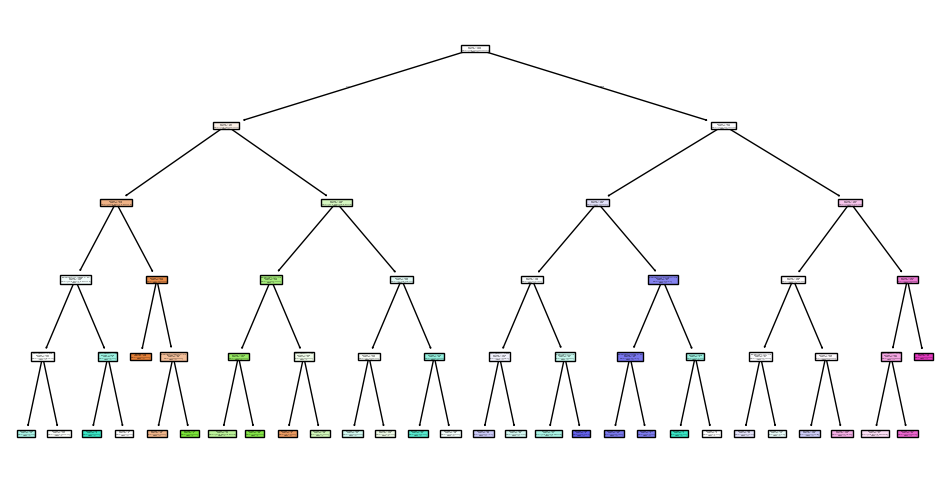

In [46]:
plt.figure(figsize=(12,6))
clf = {"ID3": id3, "C4.5": c45, "CART": cart}[best_algo]
plot_tree(clf, feature_names=X.columns, class_names=[str(x) for x in np.unique(y)], filled=True)
plt.show()

In [47]:
df_s = df.sample(2000, random_state=15)
X = pd.get_dummies(df_s[['SellerID', 'OrderDate', 'Category']])
y = bin_numeric(df_s['TotalAmount'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=15)

id3 = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=15)
c45 = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=15)
cart = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=15)
id3.fit(X_train, y_train)
c45.fit(X_train, y_train)
cart.fit(X_train, y_train)
perf = pd.DataFrame({
    "PERFORMANCE METRICES": ["ACCURRANCY", "PRECISSION", "RECALL", "F1 SCORE", "SPECIFICITY"],
    "ID3": get_metrics(y_test, id3.predict(X_test)),
    "C4.5": get_metrics(y_test, c45.predict(X_test)),
    "CART": get_metrics(y_test, cart.predict(X_test)),
})
print(perf)
best_algo = perf.iloc[0, 1:].idxmax()
print("Best algorithm for Q15:", best_algo)

  PERFORMANCE METRICES       ID3      C4.5      CART
0           ACCURRANCY  0.167500  0.167500  0.167500
1           PRECISSION  0.028056  0.028056  0.028056
2               RECALL  0.167500  0.167500  0.167500
3             F1 SCORE  0.048062  0.048062  0.048062
4          SPECIFICITY       NaN       NaN       NaN
Best algorithm for Q15: ID3


C:\Users\AID-DLL-056\AppData\Local\Temp\ipykernel_16768\150627700.py:10: RuntimeWarning: invalid value encountered in scalar divide
  specificity = (cm[0,0] / (cm[0,0] + cm[0,1])) if cm.shape[0]>1 else 0
C:\Users\AID-DLL-056\AppData\Local\Temp\ipykernel_16768\150627700.py:10: RuntimeWarning: invalid value encountered in scalar divide
  specificity = (cm[0,0] / (cm[0,0] + cm[0,1])) if cm.shape[0]>1 else 0
C:\Users\AID-DLL-056\AppData\Local\Temp\ipykernel_16768\150627700.py:10: RuntimeWarning: invalid value encountered in scalar divide
  specificity = (cm[0,0] / (cm[0,0] + cm[0,1])) if cm.shape[0]>1 else 0


In [48]:
if best_algo == "ID3":
    print("ID3 - Root Entropy:", id3.tree_.impurity[0])
elif best_algo == "C4.5":
    print("C4.5 - Root Entropy (proxy for Gain Ratio):", c45.tree_.impurity[0])
elif best_algo == "CART":
    print("CART - Root Gini Index:", cart.tree_.impurity[0])

ID3 - Root Entropy: 2.3214704617807786


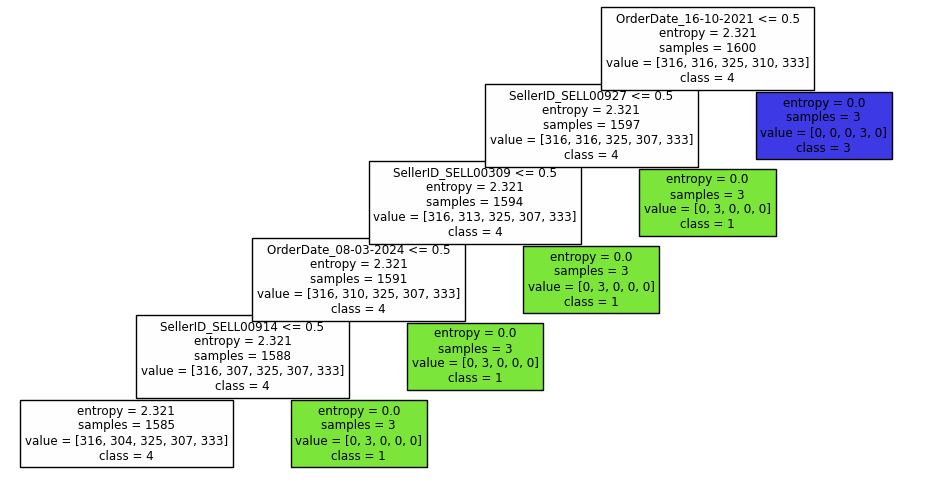

In [49]:
plt.figure(figsize=(12,6))
clf = {"ID3": id3, "C4.5": c45, "CART": cart}[best_algo]
plot_tree(clf, feature_names=X.columns, class_names=[str(x) for x in np.unique(y)], filled=True)
plt.show()

In [50]:
df_s = df.sample(2000, random_state=16)
X = pd.get_dummies(df_s[['PaymentMethod', 'OrderDate', 'ShippingCost']])
y = df_s['OrderStatus'].astype(str)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=16)

id3 = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=16)
c45 = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=16)
cart = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=16)
id3.fit(X_train, y_train)
c45.fit(X_train, y_train)
cart.fit(X_train, y_train)
perf = pd.DataFrame({
    "PERFORMANCE METRICES": ["ACCURRANCY", "PRECISSION", "RECALL", "F1 SCORE", "SPECIFICITY"],
    "ID3": get_metrics(y_test, id3.predict(X_test)),
    "C4.5": get_metrics(y_test, c45.predict(X_test)),
    "CART": get_metrics(y_test, cart.predict(X_test)),
})
print(perf)
best_algo = perf.iloc[0, 1:].idxmax()
print("Best algorithm for Q16:", best_algo)

  PERFORMANCE METRICES       ID3      C4.5      CART
0           ACCURRANCY  0.760000  0.767500  0.770000
1           PRECISSION  0.587708  0.589056  0.649516
2               RECALL  0.760000  0.767500  0.770000
3             F1 SCORE  0.662841  0.666542  0.673224
4          SPECIFICITY  0.000000  0.000000  0.000000
Best algorithm for Q16: CART


In [51]:
if best_algo == "ID3":
    print("ID3 - Root Entropy:", id3.tree_.impurity[0])
elif best_algo == "C4.5":
    print("C4.5 - Root Entropy (proxy for Gain Ratio):", c45.tree_.impurity[0])
elif best_algo == "CART":
    print("CART - Root Gini Index:", cart.tree_.impurity[0])

CART - Root Gini Index: 0.40496953125


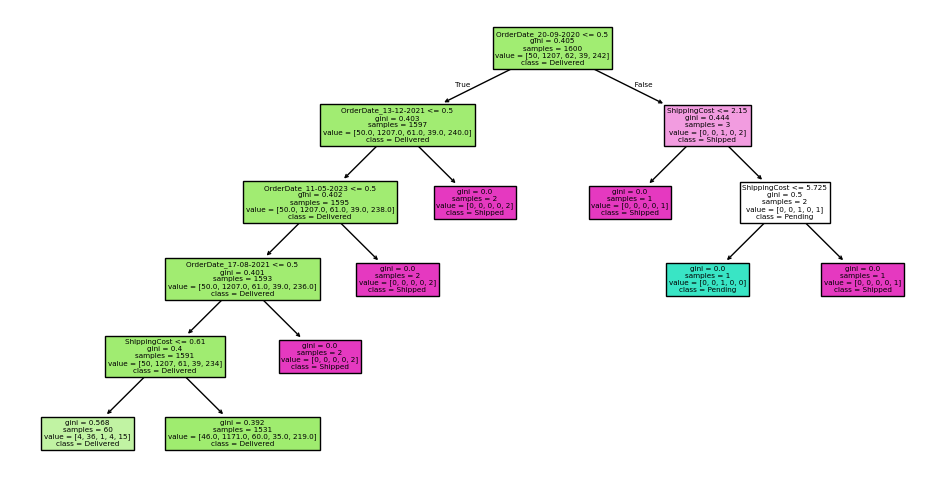

In [52]:
plt.figure(figsize=(12,6))
clf = {"ID3": id3, "C4.5": c45, "CART": cart}[best_algo]
plot_tree(clf, feature_names=X.columns, class_names=np.unique(y), filled=True)
plt.show()

In [53]:
df_s = df.sample(2000, random_state=17)
X = pd.get_dummies(df_s[['PaymentMethod', 'TotalAmount', 'Deliveredcity', 'Deliver_state']])
y = df_s['OrderStatus'].astype(str)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=17)

id3 = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=17)
c45 = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=17)
cart = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=17)
id3.fit(X_train, y_train)
c45.fit(X_train, y_train)
cart.fit(X_train, y_train)
perf = pd.DataFrame({
    "PERFORMANCE METRICES": ["ACCURRANCY", "PRECISSION", "RECALL", "F1 SCORE", "SPECIFICITY"],
    "ID3": get_metrics(y_test, id3.predict(X_test)),
    "C4.5": get_metrics(y_test, c45.predict(X_test)),
    "CART": get_metrics(y_test, cart.predict(X_test)),
})
print(perf)
best_algo = perf.iloc[0, 1:].idxmax()
print("Best algorithm for Q17:", best_algo)

  PERFORMANCE METRICES       ID3      C4.5      CART
0           ACCURRANCY  0.720000  0.740000  0.725000
1           PRECISSION  0.545064  0.547600  0.547449
2               RECALL  0.720000  0.740000  0.725000
3             F1 SCORE  0.620437  0.629425  0.623837
4          SPECIFICITY  0.000000  0.000000  0.000000
Best algorithm for Q17: C4.5


In [54]:
if best_algo == "ID3":
    print("ID3 - Root Entropy:", id3.tree_.impurity[0])
elif best_algo == "C4.5":
    print("C4.5 - Root Entropy (proxy for Gain Ratio):", c45.tree_.impurity[0])
elif best_algo == "CART":
    print("CART - Root Gini Index:", cart.tree_.impurity[0])

C4.5 - Root Entropy (proxy for Gain Ratio): 1.2185497790700888


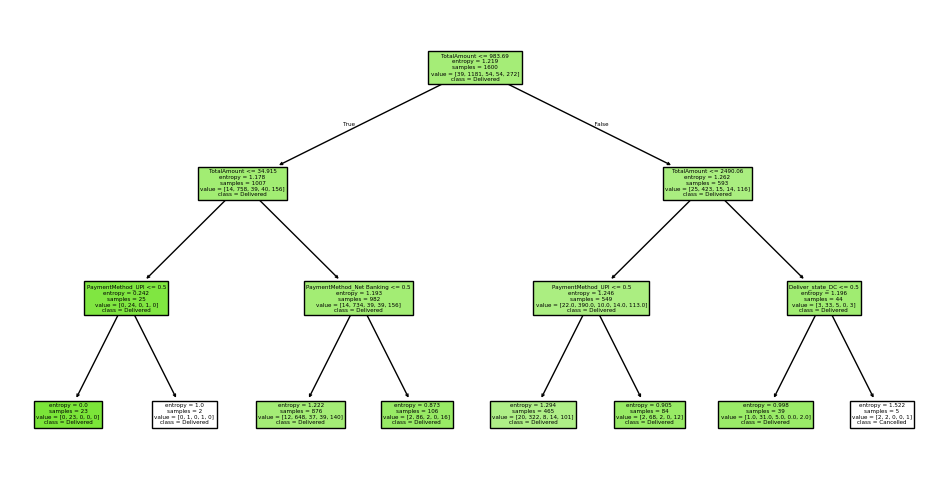

In [55]:
plt.figure(figsize=(12,6))
clf = {"ID3": id3, "C4.5": c45, "CART": cart}[best_algo]
plot_tree(clf, feature_names=X.columns, class_names=np.unique(y), filled=True)
plt.show()

In [56]:
df_s = df.sample(2000, random_state=18)
X = pd.get_dummies(df_s[['Discount', 'ShippingCost', 'Tax', 'Category']])
y = bin_numeric(df_s['TotalAmount'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=18)

id3 = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=18)
c45 = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=18)
cart = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=18)
id3.fit(X_train, y_train)
c45.fit(X_train, y_train)
cart.fit(X_train, y_train)
perf = pd.DataFrame({
    "PERFORMANCE METRICES": ["ACCURRANCY", "PRECISSION", "RECALL", "F1 SCORE", "SPECIFICITY"],
    "ID3": get_metrics(y_test, id3.predict(X_test)),
    "C4.5": get_metrics(y_test, c45.predict(X_test)),
    "CART": get_metrics(y_test, cart.predict(X_test)),
})
print(perf)
best_algo = perf.iloc[0, 1:].idxmax()
print("Best algorithm for Q18:", best_algo)

  PERFORMANCE METRICES       ID3      C4.5      CART
0           ACCURRANCY  0.585000  0.547500  0.590000
1           PRECISSION  0.577008  0.501627  0.640474
2               RECALL  0.585000  0.547500  0.590000
3             F1 SCORE  0.564876  0.513993  0.606159
4          SPECIFICITY  0.974359  0.909091  0.863014
Best algorithm for Q18: CART


In [57]:
if best_algo == "ID3":
    print("ID3 - Root Entropy:", id3.tree_.impurity[0])
elif best_algo == "C4.5":
    print("C4.5 - Root Entropy (proxy for Gain Ratio):", c45.tree_.impurity[0])
elif best_algo == "CART":
    print("CART - Root Gini Index:", cart.tree_.impurity[0])

CART - Root Gini Index: 0.79989765625


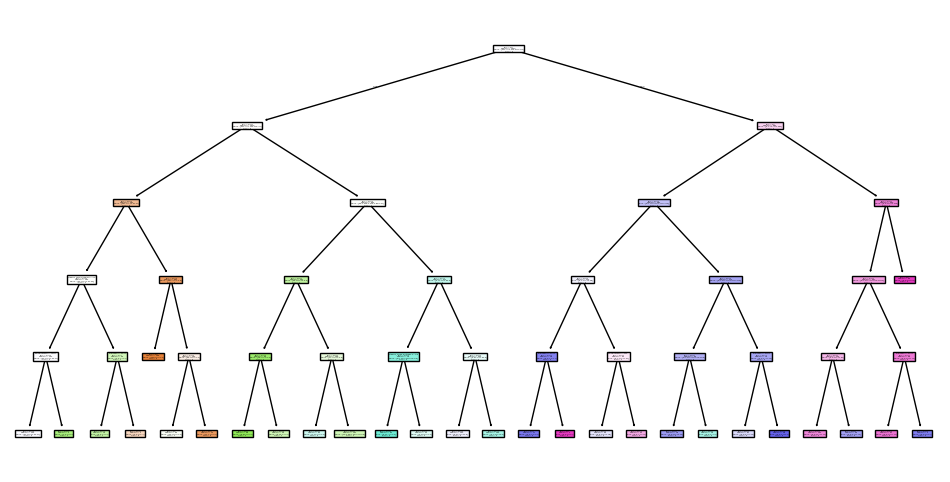

In [58]:
plt.figure(figsize=(12,6))
clf = {"ID3": id3, "C4.5": c45, "CART": cart}[best_algo]
plot_tree(clf, feature_names=X.columns, class_names=[str(x) for x in np.unique(y)], filled=True)
plt.show()

In [59]:
df_s = df.sample(2000, random_state=19)
X = pd.get_dummies(df_s[['Quantity', 'Category', 'UnitPrice']])
y = bin_numeric(df_s['Discount'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=19)

id3 = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=19)
c45 = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=19)
cart = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=19)
id3.fit(X_train, y_train)
c45.fit(X_train, y_train)
cart.fit(X_train, y_train)
perf = pd.DataFrame({
    "PERFORMANCE METRICES": ["ACCURRANCY", "PRECISSION", "RECALL", "F1 SCORE", "SPECIFICITY"],
    "ID3": get_metrics(y_test, id3.predict(X_test)),
    "C4.5": get_metrics(y_test, c45.predict(X_test)),
    "CART": get_metrics(y_test, cart.predict(X_test)),
})
print(perf)
best_algo = perf.iloc[0, 1:].idxmax()
print("Best algorithm for Q19:", best_algo)

  PERFORMANCE METRICES       ID3      C4.5      CART
0           ACCURRANCY  0.172500  0.177500  0.190000
1           PRECISSION  0.173153  0.152286  0.183366
2               RECALL  0.172500  0.177500  0.190000
3             F1 SCORE  0.149465  0.130787  0.175275
4          SPECIFICITY  0.510204  0.437500  0.400000
Best algorithm for Q19: CART


In [60]:
if best_algo == "ID3":
    print("ID3 - Root Entropy:", id3.tree_.impurity[0])
elif best_algo == "C4.5":
    print("C4.5 - Root Entropy (proxy for Gain Ratio):", c45.tree_.impurity[0])
elif best_algo == "CART":
    print("CART - Root Gini Index:", cart.tree_.impurity[0])

CART - Root Gini Index: 0.79991484375


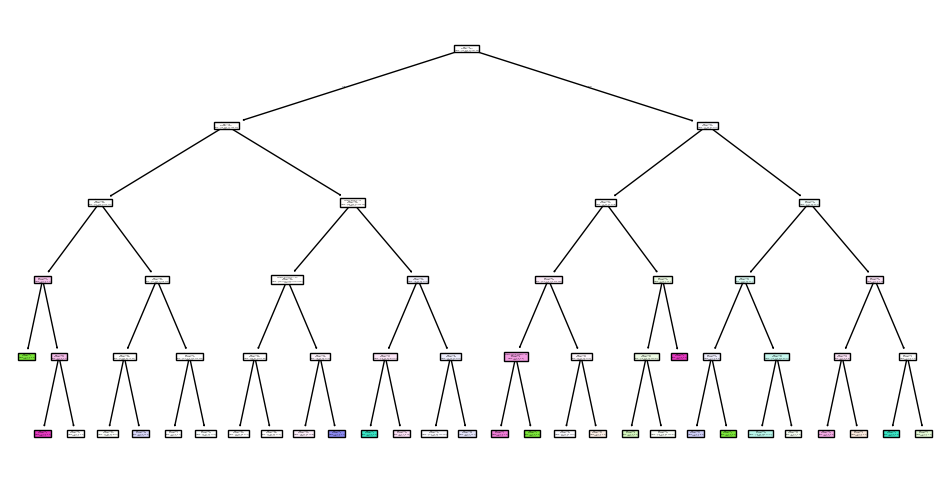

In [61]:
plt.figure(figsize=(12,6))
clf = {"ID3": id3, "C4.5": c45, "CART": cart}[best_algo]
plot_tree(clf, feature_names=X.columns, class_names=[str(x) for x in np.unique(y)], filled=True)
plt.show()

In [62]:
df_s = df.sample(2000, random_state=20)
X = pd.get_dummies(df_s[['UnitPrice', 'Quantity', 'Category', 'ProductID']])
y = bin_numeric(df_s['ShippingCost'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20)

id3 = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=20)
c45 = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=20)
cart = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=20)
id3.fit(X_train, y_train)
c45.fit(X_train, y_train)
cart.fit(X_train, y_train)
perf = pd.DataFrame({
    "PERFORMANCE METRICES": ["ACCURRANCY", "PRECISSION", "RECALL", "F1 SCORE", "SPECIFICITY"],
    "ID3": get_metrics(y_test, id3.predict(X_test)),
    "C4.5": get_metrics(y_test, c45.predict(X_test)),
    "CART": get_metrics(y_test, cart.predict(X_test)),
})
print(perf)
best_algo = perf.iloc[0, 1:].idxmax()
print("Best algorithm for Q20:", best_algo)

  PERFORMANCE METRICES       ID3      C4.5      CART
0           ACCURRANCY  0.220000  0.172500  0.195000
1           PRECISSION  0.211009  0.155784  0.255212
2               RECALL  0.220000  0.172500  0.195000
3             F1 SCORE  0.139563  0.107443  0.141819
4          SPECIFICITY  0.166667  0.000000  0.111111
Best algorithm for Q20: ID3


In [63]:
if best_algo == "ID3":
    print("ID3 - Root Entropy:", id3.tree_.impurity[0])
elif best_algo == "C4.5":
    print("C4.5 - Root Entropy (proxy for Gain Ratio):", c45.tree_.impurity[0])
elif best_algo == "CART":
    print("CART - Root Gini Index:", cart.tree_.impurity[0])

ID3 - Root Entropy: 2.321585655279479


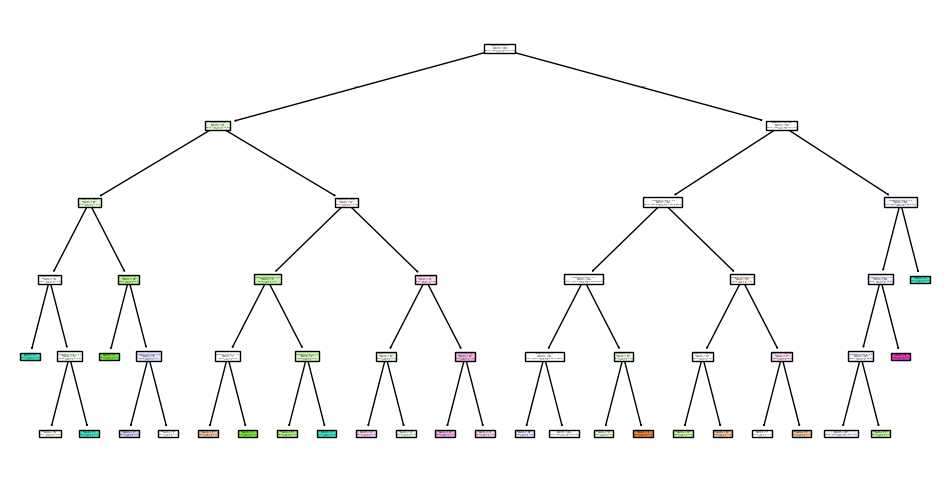

In [64]:
plt.figure(figsize=(12,6))
clf = {"ID3": id3, "C4.5": c45, "CART": cart}[best_algo]
plot_tree(clf, feature_names=X.columns, class_names=[str(x) for x in np.unique(y)], filled=True)
plt.show()